In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# add repo root so swiss_roll_models can be imported from anywhere
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "swiss_roll_models").exists():
        sys.path.insert(0, str(p))
        break

from functions.dataset import generate_swiss_roll
from functions.Hilbert_computation import hilbert_computation as hbc
import functions.graph_print_analysis as gp_tools
# positive linear model = softplus(theta) ∈ R^D_{>0}
class PositiveLinear(nn.Module):
    def __init__(self, D):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(D))  # trainable parameters
    def forward(self, X):
        w = F.softplus(self.theta)
        return X @ w

    def positive_params_vector(self):
        # Return the current positive parameter vector for Hilbert distance calculation
        return F.softplus(self.theta).detach().clone()


In [2]:
def run_experiment_on_subset(
    X_full : torch.Tensor,
    y_full : torch.Tensor,
    n: int,
    num_epochs : int = 500,
    lr : float = 1e-2,
    l2_reg : float = 1e-3,
    device : str = 'cuda',
    seed : int = 114514,
    batch_size : int = None,
) -> dict:
        
    """
    Run training on a random subset of size n from (X_full, y_full).
        Args:
            X_full: Full input data tensor of shape (N, D).
            y_full: Full target data tensor of shape (N,).
            n: Size of the subset to sample for training.
            num_epochs: Number of training epochs.
            lr: Learning rate for SGD.
            l2_reg: L2 regularization coefficient.
            device: Device to run the computations on ("cuda" or "cpu").

        Returns:
            A dictionary containing:
                - 'n': The subset size used.
                - 'loss_traj': List of loss values per epoch.
                - 'param_traj': List of parameter vectors per epoch.
                - 'w_star': Final learned positive parameter vector.
    """
    if batch_size is None:
        batch_size = n  # full-batch
    torch.manual_seed(seed)
    N, D = X_full.shape
    idx = torch.randperm(N, device=device)[:n]
    X = X_full[idx]
    y = y_full[idx]
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)  # full-batch

    model = PositiveLinear(D).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    param_traj = []
    loss_traj = []
    mse_traj = []
    l2_traj = []
    theta_traj = []

    for epoch in range(num_epochs):
        for batch_X, batch_y in loader:
            optimizer.zero_grad()

            # 1. prediction
            y_pred = model(batch_X)

            # 2. MSE part
            mse = F.mse_loss(y_pred, batch_y)

            # 3. L2 regularization: regularize w = softplus(theta) in the positive cone
            w = F.softplus(model.theta)
            l2 = (w ** 2).sum()

            # 4. Total loss = mse + λ ||w||^2
            loss = mse + l2_reg * l2

            loss.backward()
            optimizer.step()
        with torch.no_grad():
            theta_t=model.theta.detach().cpu().clone()
            w_t=model.positive_params_vector().cpu().clone()
        loss_traj.append(loss.item())
        mse_traj.append(mse.item())
        l2_traj.append(l2.item())
        param_traj.append(w_t)
        theta_traj.append(theta_t)


    w_star = param_traj[-1]

    prev = param_traj[0]
    return {
        "n": n,
        "num_epochs": num_epochs,
        "lr": lr,
        "l2_reg": l2_reg,
        "seed": seed,
        "loss_traj": loss_traj,
        "mse_traj": mse_traj,
        "l2_traj": l2_traj,
        "param_traj": param_traj,   # list length = num_epochs+1
        "theta_traj": theta_traj,   # optional, to observe inside/outside the cone
        "w_star": w_star,
    }


In [3]:

from matplotlib.ticker import MaxNLocator


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ----- Generate Swiss roll -----
N = 50_000
D = 280
X_full, y_full, u, v = generate_swiss_roll(
    n_samples=N,
    D=D,
    noise=53,
    device=device,
)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")

# ----- Different small sample sizes -----
n_list = [50, 100, 200, 500]
num_epochs = 150
lr = 1e-3
l2_list = [0,1e-3,1e-2,1e-1]
l2 = l2_list[2]
first_20s=[]
other_20s=[]
# all_results[n][l2_reg] = corresponding experiment results
all_results = {}
n=9128
names=[]

Using device: cuda
Full dataset: X=torch.Size([50000, 280]), y=torch.Size([50000])


In [4]:

for n in n_list:
    print(f"\n================ n = {n} ================")
    title = f"n={n} and l2_reg={l2}"
    print(f"\n--- Running experiment as {title} ---")
    res = run_experiment_on_subset(
        X_full,
        y_full,
        n=n,
        # num_epochs=num_epochs,
        lr=lr,
        l2_reg= l2,
        device=device,
        seed=27189045,
    )
    names.append(title)
    all_results[title] = res  
    w = res['w_star']
    trajectory = res['param_traj']
    first_20_param = trajectory[:20]
    w_20 = trajectory[20]
    other_20_param = trajectory[20:-1]
    hdist_traj=hbc.compute_hilbert_to_w_star(trajectory=first_20_param, w_star=w_20)
    hdist_traj2=hbc.compute_hilbert_to_w_star(trajectory=other_20_param, w_star=trajectory[-1])
    first_20 = hdist_traj
    other_20 = hdist_traj2
    first_20s.append(first_20)
    other_20s.append(other_20)
    




================ n = 50 ================

--- Running experiment as n=50 and l2_reg=0.01 ---

================ n = 100 ================

--- Running experiment as n=100 and l2_reg=0.01 ---

================ n = 200 ================

--- Running experiment as n=200 and l2_reg=0.01 ---

================ n = 500 ================

--- Running experiment as n=500 and l2_reg=0.01 ---


4


<Figure size 800x600 with 0 Axes>

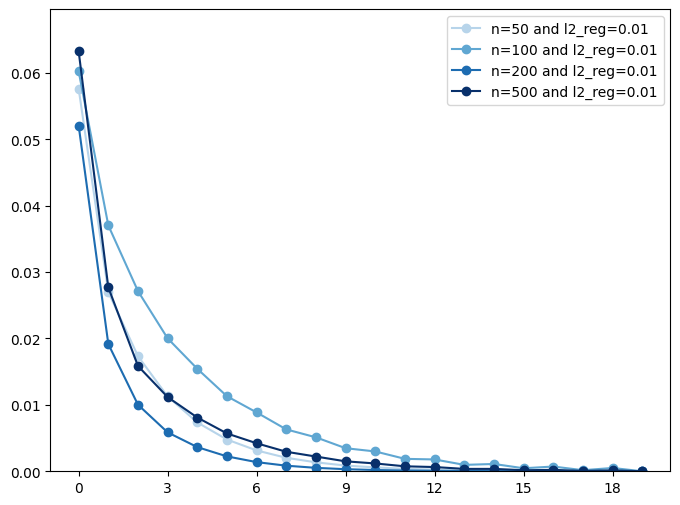

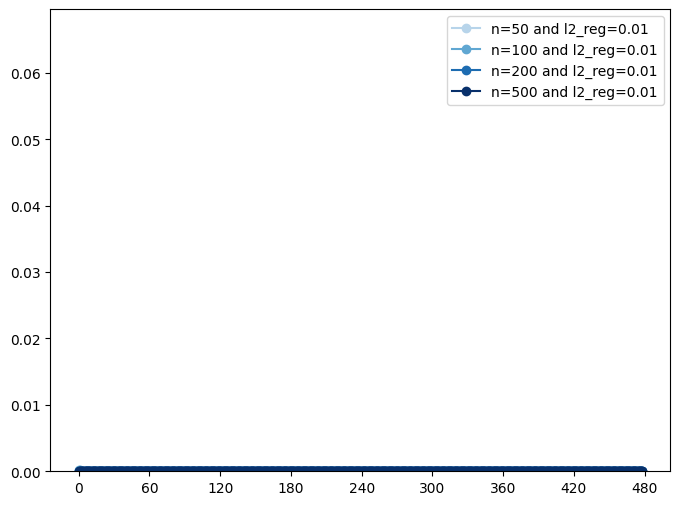

In [5]:
fig = plt.figure(figsize=(8, 6))
y_min = 0
y_max = max(
    max(max(group) for group in first_20s),
    max(max(group) for group in other_20s)
) * 1.1
print(len(first_20s))
import matplotlib.cm as cm
plt.figure(figsize=(8, 6)) 
plt.ylim(y_min, y_max)
plt.xscale('linear')
plt.yscale('linear')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
num_groups = len(first_20s)

start, end = 0.3, 1.0
colors = cm.Blues([start + (end - start) * i / (num_groups - 1) for i in range(num_groups)])
for i, first_20 in enumerate(first_20s):
    first_20
    plt.plot(range(len(first_20)), first_20, marker='o', color=colors[i],label=names[i])

plt.legend()
plt.show()


plt.figure(figsize=(8, 6))
plt.ylim(y_min, y_max)
plt.xscale('linear')
plt.yscale('linear')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
for i, other_20 in enumerate(other_20s):
    plt.plot(range(len(other_20)), other_20, marker='o', color=colors[i],label=names[i])
plt.legend()
plt.show()

In [6]:
import numpy as np
print(all_results.keys())
res=all_results[names[0]]

dict_keys(['n=50 and l2_reg=0.01', 'n=100 and l2_reg=0.01', 'n=200 and l2_reg=0.01', 'n=500 and l2_reg=0.01'])


In [7]:
hilbert_to_final=hbc.compute_hilbert_to_w_star(res['param_traj'],res['w_star'],)
l2_to_final=np.linalg.norm(np.array(res['param_traj'])-res['w_star'].cpu().numpy(),axis=1)
cos_to_final=res['param_traj']@res['w_star'].cpu().numpy()/(np.linalg.norm(np.array(res['param_traj']),axis=1)*np.linalg.norm(res['w_star'].cpu().numpy()))
loss_traj=res['loss_traj']
print(first_20s[2])

[0.052065631241245136, 0.01915860399385038, 0.010020577690891798, 0.005858027854117337, 0.0036391164557552807, 0.0022418029702760025, 0.0013800089202744767, 0.0008413385268396447, 0.0005176890986720799, 0.00031247337968315516, 0.00019412287558448862, 0.00011477344058478412, 7.375304687278554e-05, 4.1196805628637955e-05, 2.8820779654588162e-05, 1.3798360276349141e-05, 1.2027599863296065e-05, 3.7486780637724415e-06, 5.936951226790216e-06, 0.0]


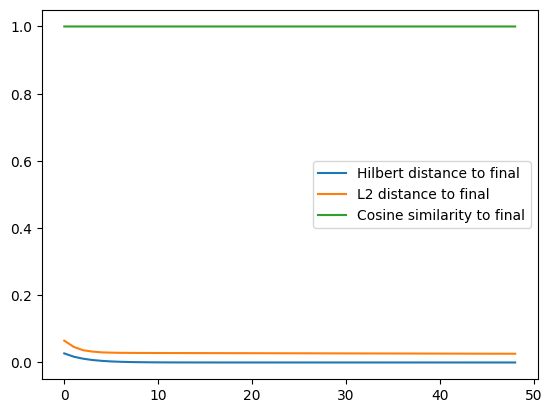

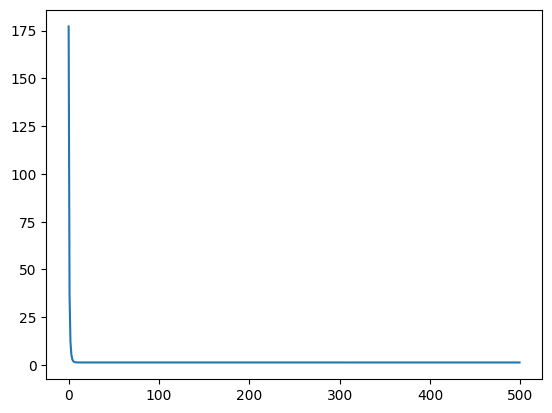

In [8]:
plt.plot(hilbert_to_final[1:50],label='Hilbert distance to final',)
plt.plot(l2_to_final[1:50],label='L2 distance to final')
plt.plot(cos_to_final[1:50],label='Cosine similarity to final')
plt.legend()
plt.show()
plt.plot(loss_traj,label='Loss trajectory')

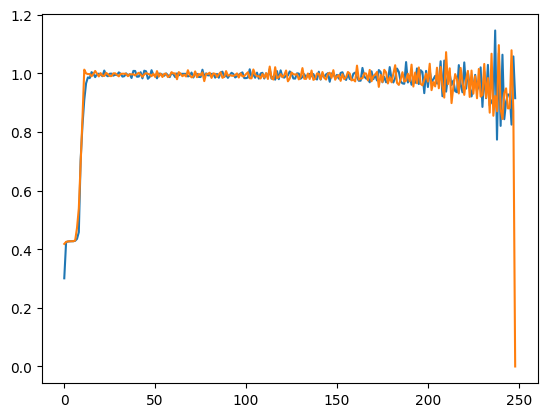

In [9]:
h = np.array(hilbert_to_final)
h_even = h[0::2]
h_odd  = h[1::2]

ratio_even = h_even[1:] / h_even[:-1]   # 每两步之间的收缩比例，真正对应 |λ|^2
ratio_odd  = h_odd[1:] / h_odd[:-1]
plt.plot(ratio_even,label='Even step ratio')
plt.plot(ratio_odd,label='Odd step ratio')

In [10]:
from sklearn.decomposition import PCA
trajectory = res['param_traj']
w_traj = np.array(trajectory[1:20])    # shape: (T+1, D)
w_star = res['w_star'].cpu().numpy()  # shape: (D,
R = w_traj - w_star          # shape: (T+1, D)
pca = PCA(n_components=1)
pca.fit(R)
v = pca.components_[0]       # 主方向，单位向量

a = R @ v                    # shape: (T+1,)
print('first 20 largest eigenvalue',a)
numpy_hilbert_to_final20=np.array(hilbert_to_final[:20])
print('hilbert to final first 20 steps',numpy_hilbert_to_final20)


first 20 largest eigenvalue [-5.78921847e-02  3.61191928e-02 -2.21367851e-02  1.47628365e-02
 -8.94099288e-03  6.39747083e-03 -3.57481092e-03  2.92155659e-03
 -1.31841935e-03  1.44888030e-03 -3.60096252e-04  8.20620917e-04
  4.80041490e-05  5.51587669e-04  2.21225084e-04  4.36002389e-04
  2.94399943e-04  3.85753519e-04  3.24895285e-04]
hilbert to final first 20 steps [5.76136773e-02 2.69950510e-02 1.73200000e-02 1.12807375e-02
 7.34004042e-03 4.79198485e-03 3.12639534e-03 2.04310961e-03
 1.33417998e-03 8.72151385e-04 5.69718942e-04 3.72493941e-04
 2.43406916e-04 1.59073109e-04 1.04325574e-04 6.83989897e-05
 4.53798919e-05 3.22981695e-05 2.07852074e-05 1.73981545e-05]


In [11]:
hilbert_to_betwee=hbc.compute_hilbert_between_steps(res['param_traj'])
vector_hilbert_between_steps=np.array(hilbert_to_betwee)
print(vector_hilbert_between_steps[:20])
ratio_to_between=vector_hilbert_between_steps[1:20]/vector_hilbert_between_steps[0:19]


[8.42137082e-02 4.38614491e-02 2.86007375e-02 1.86207779e-02
 1.21320253e-02 7.91838019e-03 5.16950495e-03 3.37728959e-03
 2.20633136e-03 1.44187033e-03 9.42212883e-04 6.15900856e-04
 4.02480024e-04 2.62936378e-04 1.71893706e-04 1.12377502e-04
 7.34492154e-05 4.78995229e-05 3.12699601e-05 2.05014869e-05]
